The objective of this project is to build machine learning models to predict whether a patient has diabetes based on medical attributes. In this notebook, Support Vector Machine (SVM) with different kernels and K-Nearest Neighbors (KNN) are implemented and their performances are compared using standard evaluation metrics.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [31]:
#Load Dataset
df = pd.read_csv('/content/diabetes.csv')

Basic exploratory analysis is performed to understand the dataset. This includes checking the dataset shape, column names, data types, descriptive statistics, and identifying any missing values.

In [32]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
df.shape

(768, 9)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [35]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [36]:
#Check Missing Values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [37]:
#Replace Invalid Zero Values
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

Columns such as Glucose, BloodPressure, SkinThickness, Insulin and BMI cannot realistically be zero.

In [38]:
#Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

The dataset is divided into training and testing sets. The training data is used to build the models, while the testing data is used to evaluate their performance on unseen samples.

In [39]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,)

In [40]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The first SVM model is trained using the Linear kernel. This kernel works well when the data is approximately linearly separable.

In [41]:
#Support Vector Machine (SVM)
#Linear Kernel
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_linear))

Accuracy: 0.7662337662337663


In [43]:
print(confusion_matrix(y_test, y_pred_linear))

[[83 16]
 [20 35]]


In [44]:
print(classification_report(y_test, y_pred_linear))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



The RBF (Radial Basis Function) kernel is used to capture nonlinear relationships between the features and the target variable.

In [45]:
#RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))

Accuracy: 0.7532467532467533
[[84 15]
 [23 32]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82        99
           1       0.68      0.58      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



The Sigmoid kernel is another nonlinear kernel that behaves similarly to a neural network activation function. Its performance is compared with other kernels.

In [47]:
#Sigmoid Kernel
svm_sigmoid = SVC(kernel='sigmoid')
svm_sigmoid.fit(X_train, y_train)
y_pred_sigmoid = svm_sigmoid.predict(X_test)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print(confusion_matrix(y_test, y_pred_sigmoid))
print(classification_report(y_test, y_pred_sigmoid))

Accuracy: 0.6948051948051948
[[80 19]
 [28 27]]
              precision    recall  f1-score   support

           0       0.74      0.81      0.77        99
           1       0.59      0.49      0.53        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



The Polynomial kernel is trained to model polynomial relationships between the input features and the target class.

In [49]:
#Polynomial Kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))
print(classification_report(y_test, y_pred_poly))

Accuracy: 0.7467532467532467
[[89 10]
 [29 26]]
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        99
           1       0.72      0.47      0.57        55

    accuracy                           0.75       154
   macro avg       0.74      0.69      0.70       154
weighted avg       0.74      0.75      0.73       154



The KNN classifier is implemented to classify patients based on the nearest neighboring data points. Different values of K are tested to determine the best performance.

In [51]:
#Elbow Method for KNN
error_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error = np.mean(pred_k != y_test)
    error_rate.append(error)

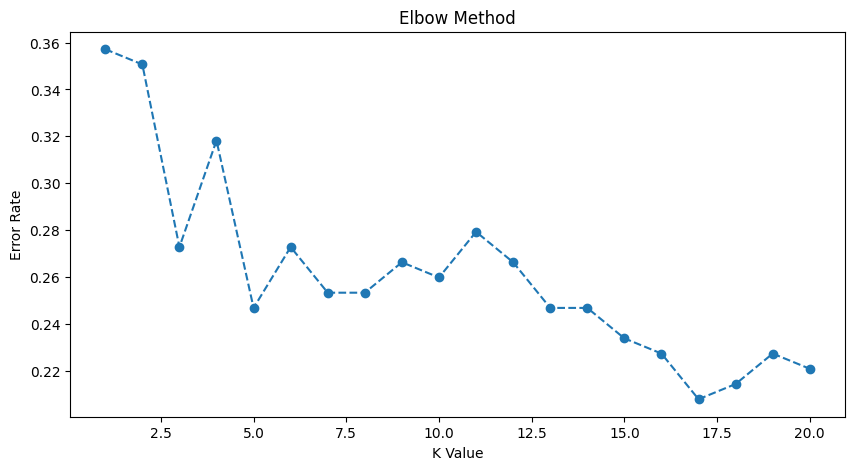

In [52]:
plt.figure(figsize=(10,5))
plt.plot(
    range(1,21),
    error_rate,
    marker='o',
    linestyle='--'
)
plt.title('Elbow Method')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

From this elbow graph we get that the best k value to use is 17

In [53]:
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.7922077922077922


In [55]:
print(confusion_matrix(y_test, y_pred_knn))

[[88 11]
 [21 34]]


In [56]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85        99
           1       0.76      0.62      0.68        55

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



In [57]:
#Compare Models
results = pd.DataFrame({
    'Model':[
        'SVM Linear',
        'SVM RBF',
        'SVM Sigmoid',
        'SVM Polynomial',
        'KNN'
    ],
    'Accuracy':[
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_sigmoid),
        accuracy_score(y_test, y_pred_poly),
        accuracy_score(y_test, y_pred_knn)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
4,KNN,0.792208
0,SVM Linear,0.766234
1,SVM RBF,0.753247
3,SVM Polynomial,0.746753
2,SVM Sigmoid,0.694805


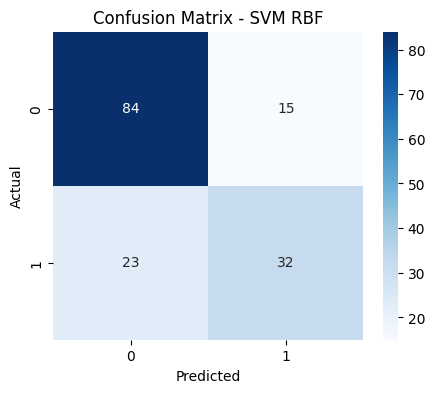

In [58]:
cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM RBF")
plt.show()

All four SVM kernels were successfully trained and evaluated.
The KNN classifier was trained using the optimal K obtained from the Elbow Method.
The performance of each model was compared using accuracy, confusion matrix, and classification report.
The model with the highest accuracy provided the best prediction performance on the test dataset and was found to be KNN model. The RBF kernel generally performs well for nonlinear datasets, while KNN performance depends heavily on the selected value of K. Choosing the appropriate model and parameters significantly improves prediction accuracy.